# Taller de Regresión Lineal Simple


## Punto 1: Introducción a la Regresión Lineal Simple

En este punto vamos a:
1. Genere un conjunto de datos aleatorios que contenga 20 puntos.
2. Utilice la biblioteca `scikit-learn` para ajustar un modelo de regresión lineal simple.
3. Grafique los puntos y la línea de regresión.

In [14]:
# Importar librerías 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

### 1.1 Generación del conjunto de datos aleatorios

In [15]:
# Generar datos simulados
np.random.seed(0)
X = 2 * np.random.rand(20, 1) * 10  
y = 5 + 3 * X + np.random.randn(20, 1) * 5

print("Valores de X:")
print(X.ravel())
print("\nValores de y:")
print(y.ravel())

Valores de X:
[10.97627008 14.30378733 12.05526752 10.89766366  8.47309599 12.91788226
  8.75174423 17.83546002 19.27325521  7.66883038 15.83450076 10.5778984
 11.36089122 18.51193277  1.42072116  1.74258599  0.40436795 16.65239691
 15.56313502 17.40024296]

Valores de y:
[45.3992056  46.88557066 42.73114107 33.42251228 17.65433888 47.02173976
 35.57741367 54.79555494 74.16853875 20.73466276 52.73229487 35.79777594
 46.74656974 67.88259215 10.03690062 12.11857058  1.77417511 45.05320839
 49.94984431 57.98247374]


### 1.2 Ajuste del modelo de regresión lineal simple con scikit-learn

In [ ]:
modelo_p1 = LinearRegression()
# Entrenamos el modelo 
modelo_p1.fit(X, y)
# Obtenemos los parámetros estimados 
intercepto = modelo_p1.intercept_[0]
pendiente = modelo_p1.coef_[0][0]

print(f"Intercepto (a): {intercepto:.4f}")
print(f"Pendiente (b): {pendiente:.4f}")
print(f"Ecuación de la recta ajustada: y = {intercepto:.4f} + {pendiente:.4f} * X")

Intercepto (a): 2.3115
Pendiente (b): 3.2337
Ecuación de la recta ajustada: y = 2.3115 + 3.2337 * X


### 1.3 Gráfico de los puntos y la línea de regresión

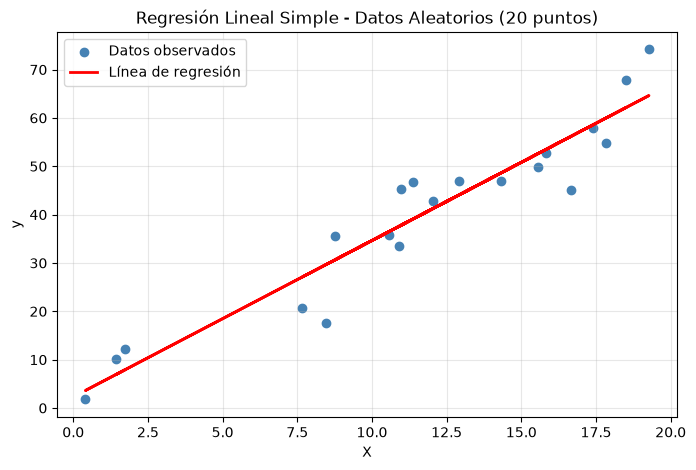

In [17]:
y_pred_p1 = modelo_p1.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='steelblue', label='Datos observados')
plt.plot(X, y_pred_p1, color='red', linewidth=2, label='Línea de regresión')
plt.title('Regresión Lineal Simple - Datos Aleatorios (20 puntos)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Punto 2: Análisis de Residuos

En este punto vamos a:
1. Utilice el conjunto de datos de iris disponible en la biblioteca `seaborn`.
2. Realice una regresión lineal simple para predecir el ancho del pétalo basado en su longitud.
3. Calcule los residuos y grafique un histograma para analizar su distribución.

In [18]:
# Importar librerías necesarias
import seaborn as sns
import pandas as pd

### 2.1 Carga del conjunto de datos iris

In [19]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2.2 Regresión lineal simple: longitud del pétalo vs. ancho del pétalo

In [20]:
# Variable independiente: longitud del pétalo
X_iris = iris[['petal_length']]

# Variable dependiente: ancho del pétalo
y_iris = iris['petal_width']

# Crear el modelo de regresión lineal
modelo_p2 = LinearRegression()
# Entrenar el modelo
modelo_p2.fit(X_iris, y_iris)

# Parámetros estimados
print(f"Intercepto: {modelo_p2.intercept_:.4f}")
print(f"Pendiente: {modelo_p2.coef_[0]:.4f}")

# Predicciones del modelo
y_pred_iris = modelo_p2.predict(X_iris)

Intercepto: -0.3631
Pendiente: 0.4158


### 2.3 Cálculo de los residuos

In [21]:
residuos_iris = y_iris - y_pred_iris

print("Estadísticas descriptivas de los residuos:")
print(residuos_iris.describe())

Estadísticas descriptivas de los residuos:
count    1.500000e+02
mean    -1.006602e-16
std      2.057903e-01
min     -5.651548e-01
25%     -1.235793e-01
50%     -1.898206e-02
75%      1.328758e-01
max      6.427229e-01
Name: petal_width, dtype: float64


### 2.4 Histograma de los residuos

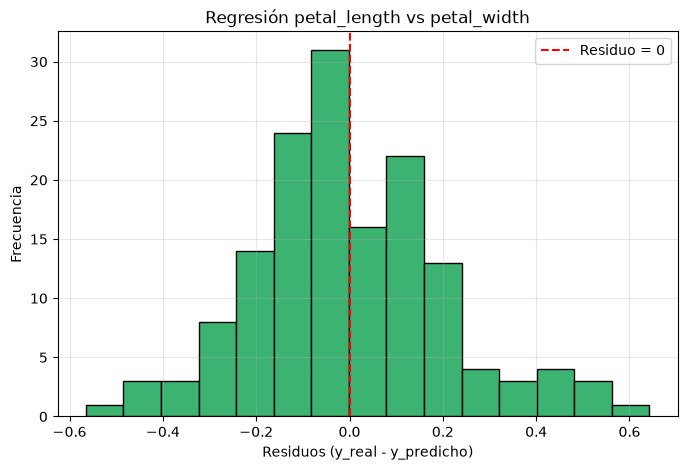

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(residuos_iris, bins=15, color='mediumseagreen', edgecolor='black')
plt.title('Regresión petal_length vs petal_width')
plt.xlabel('Residuos (y_real - y_predicho)')
plt.ylabel('Frecuencia')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Residuo = 0')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interpretación:** Si el histograma de los residuos muestra una forma aproximadamente simétrica y centrada en cero, esto sugiere que los residuos siguen una distribución cercana a la normal, lo cual es un buen indicio de que el supuesto de normalidad del modelo de regresión lineal se cumple razonablemente.